In [1]:
%load_ext autoreload
%autoreload 2

In [24]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle
from specparam import SpectralModel
from specparam import Bands
import neurodsp as ndp
from scipy.stats import zscore

# NeuroDSP scipy and FOOOF modules
from neurodsp import spectral




# Custom modules
from lfp_spike_window_analysis import *

from spe1_plotting import *
from signal_utils import * 
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS

### HELPER FUNCTIONS - to do: move to .py file 

### Set up

In [3]:
cell_num =42 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

#### Step 0: Get loaded data

In [4]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c42_lfp_filt.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c42patch_filt.npy'

In [5]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

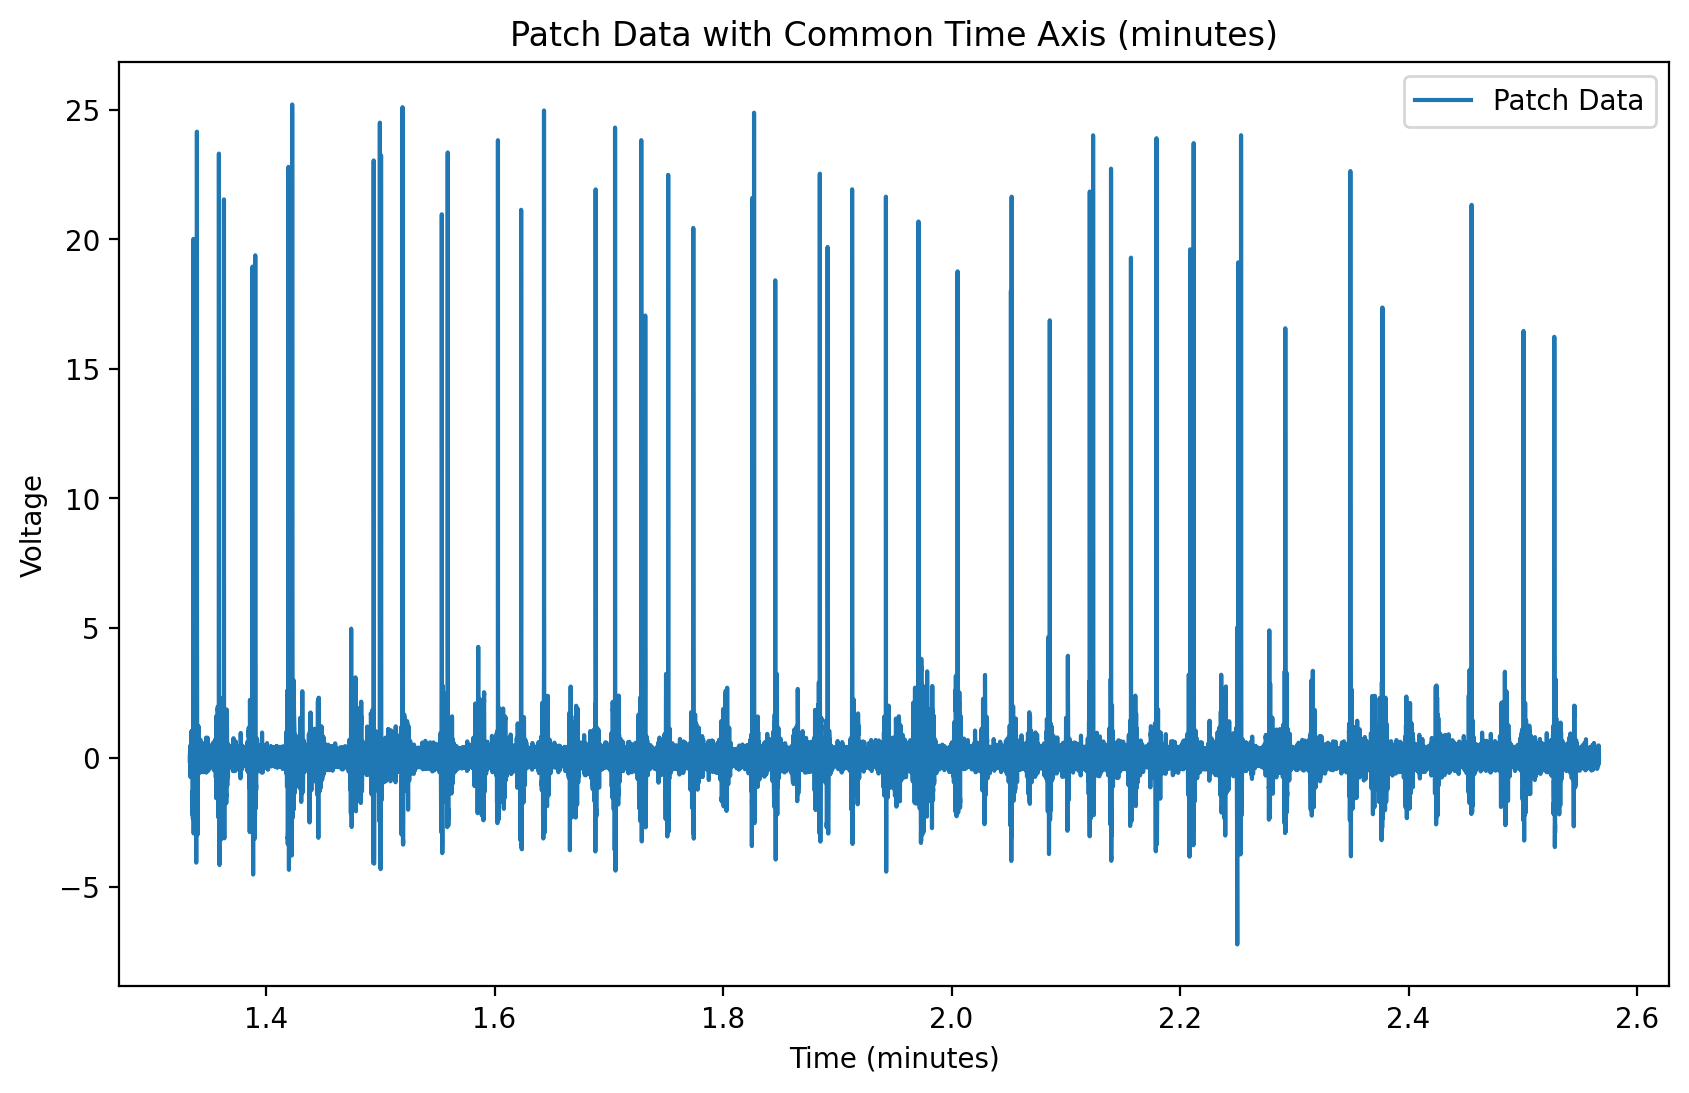

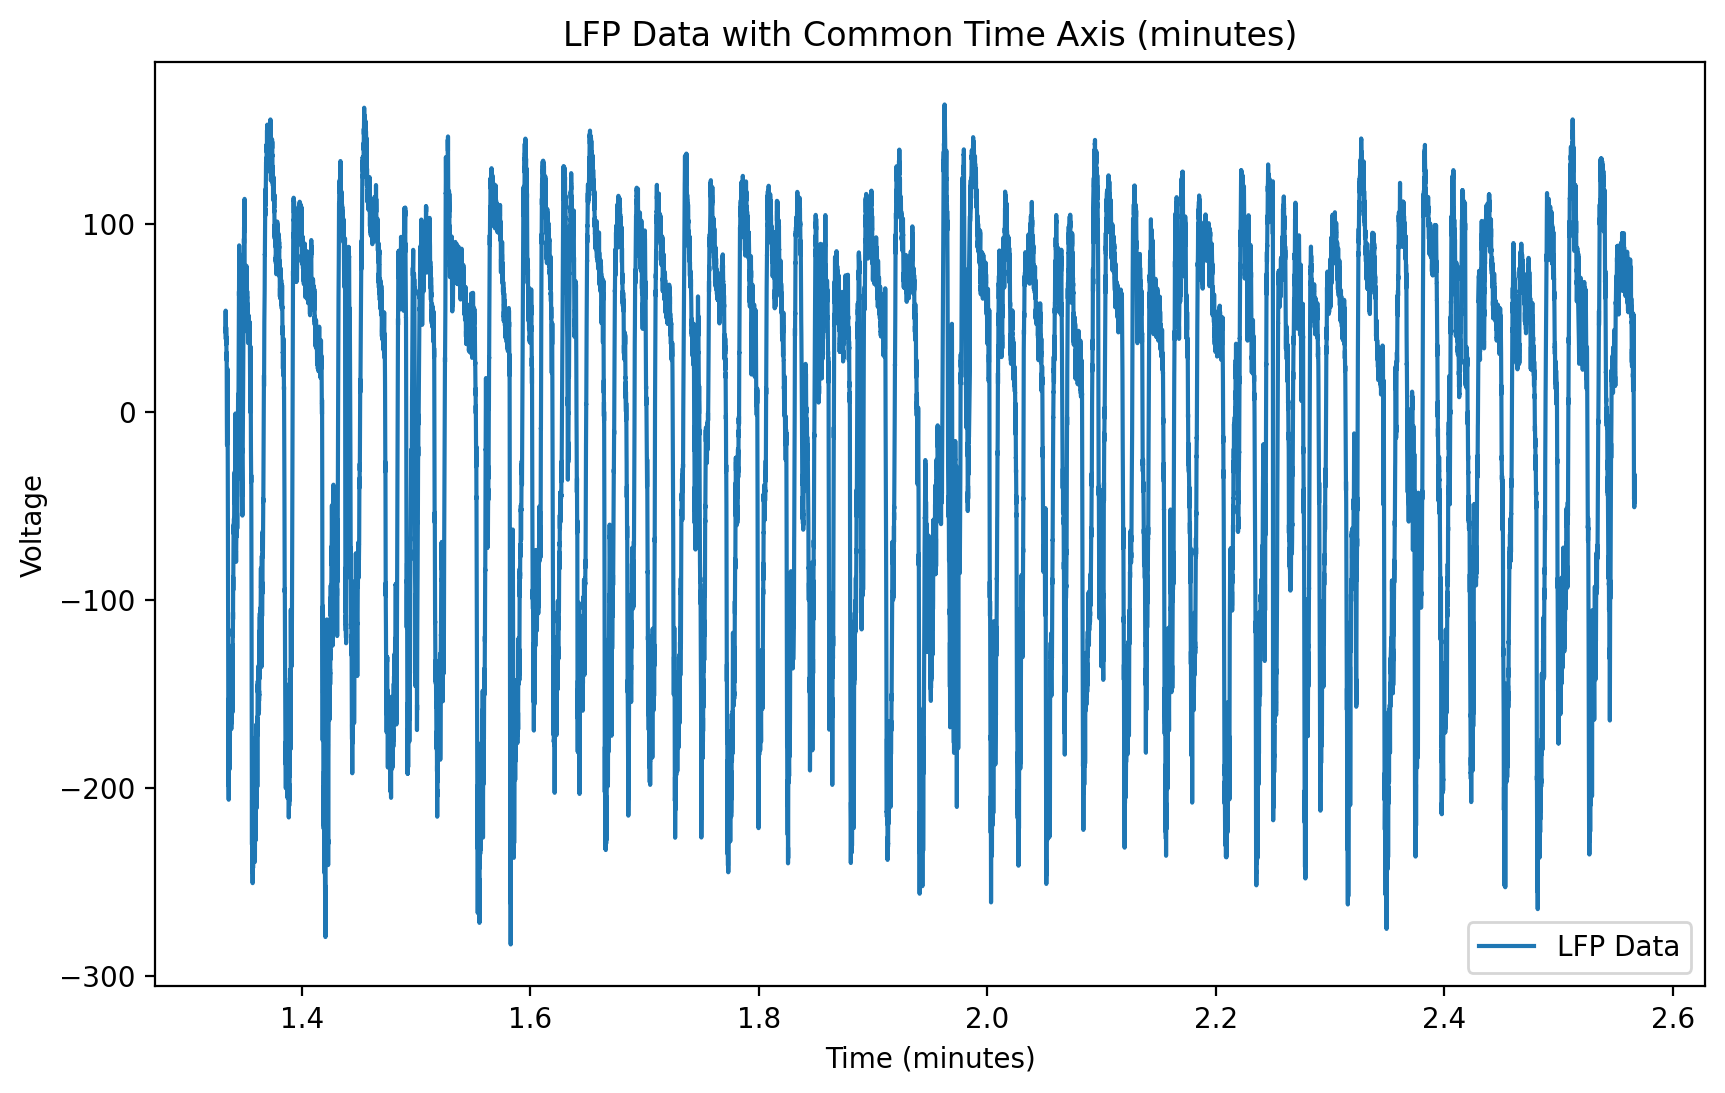

In [6]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 25.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: ANALYZE LFP DATA

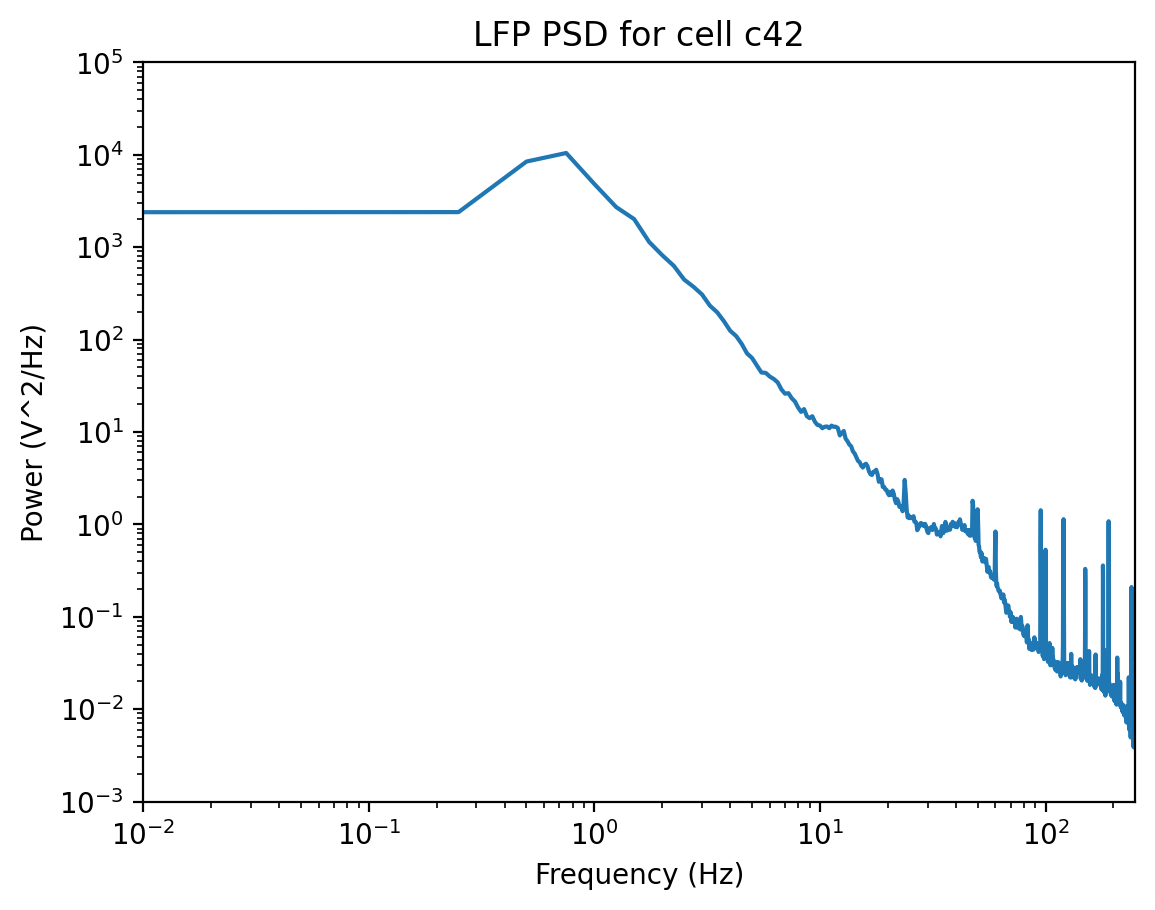

In [7]:

# plot power spectrum
fxx, pxx = spectral.compute_spectrum(lfp_filt, lfp_fs, method='welch', window='hann', nperseg=lfp_fs*4)

xlim = (10e-3, 250)
ylim = (10e-4, 10e4)
plt.loglog(fxx, pxx)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (V^2/Hz)')
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("LFP PSD for cell "+ cell_num)
plt.show()


### There seem to be some gamma oscillations 

#### 0. Use specpram to find gamma peaks

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


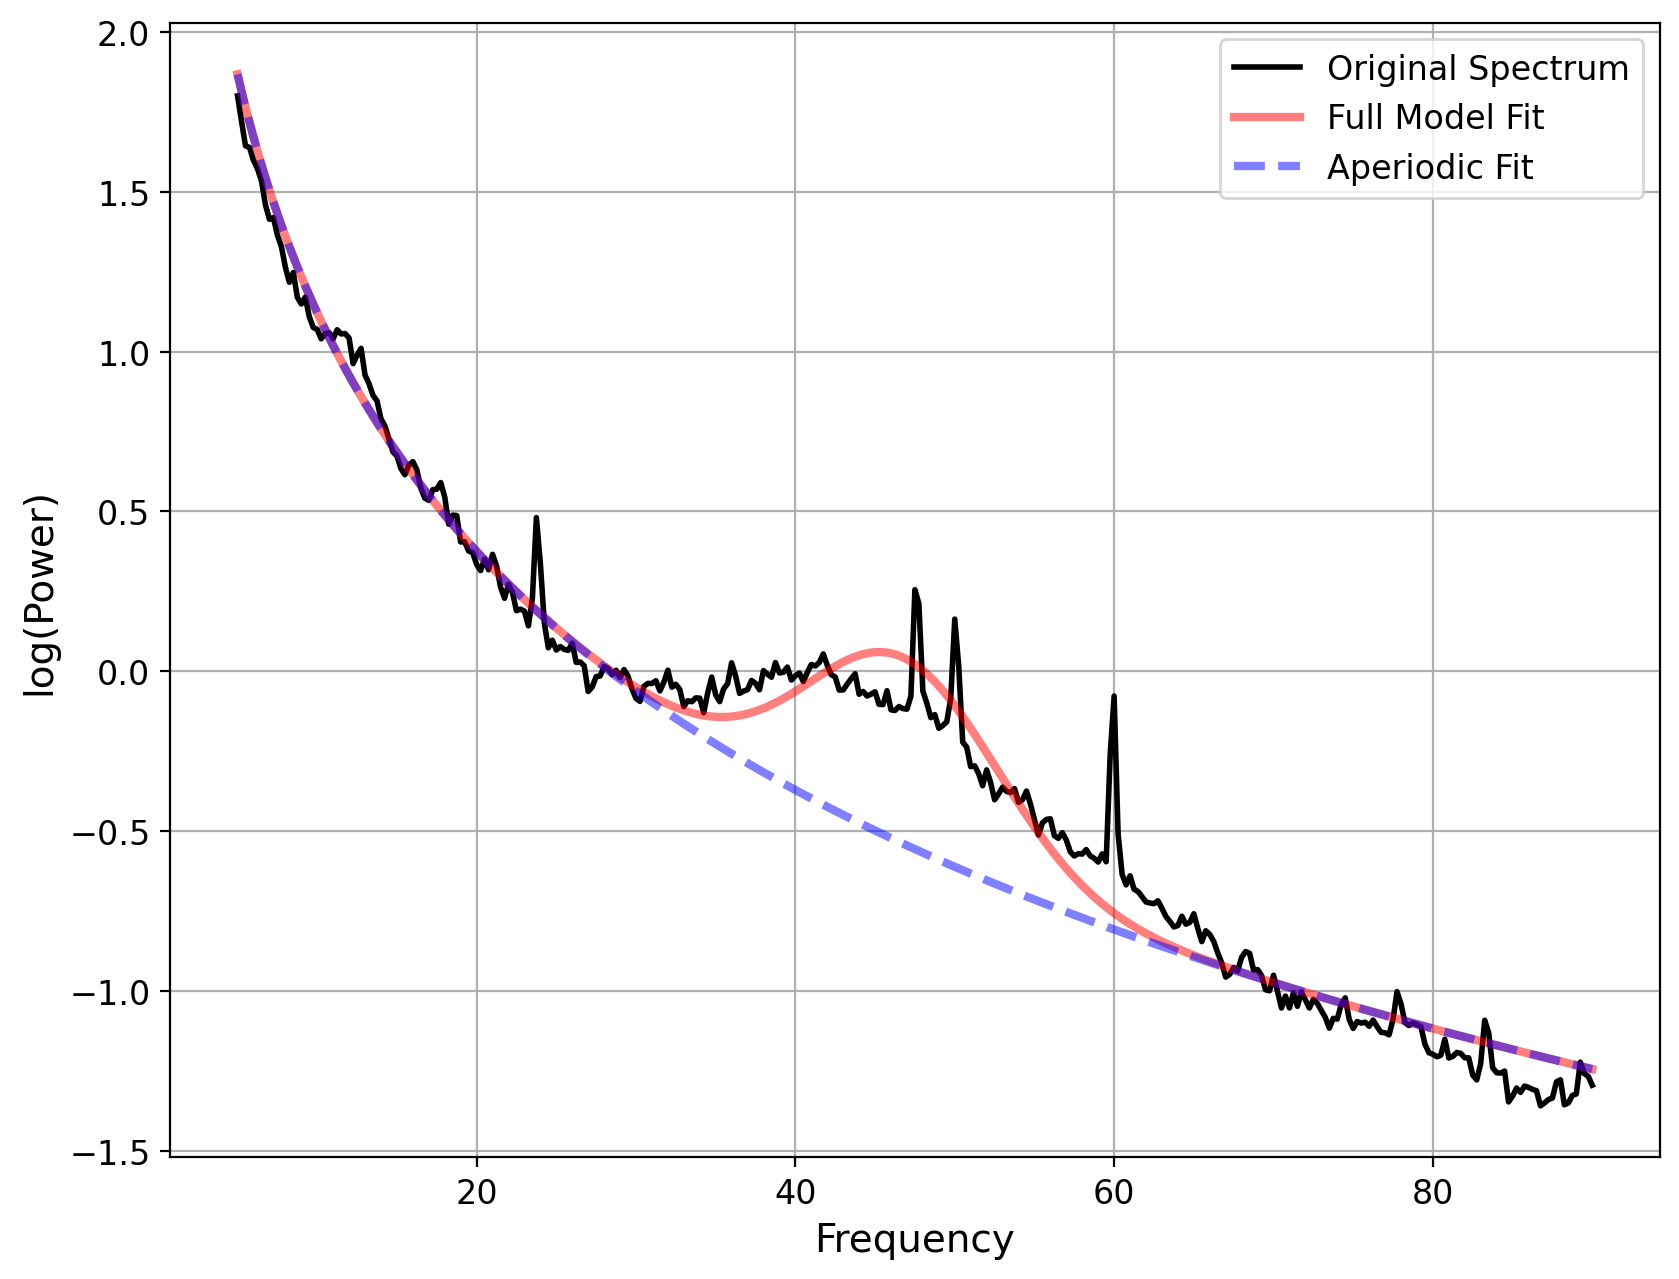

In [8]:
fm = SpectralModel(max_n_peaks=1, verbose=False)
fm.fit(fxx, pxx, freq_range=(5,90))
fm.plot()

# A) Long window specparam for kilosort

In [9]:

# SHARED PARAMETERS
lfp_signal = lfp_filt
fs = lfp_fs

# Windowing parameters
window_len_sec = 2
step_size_sec = 1

# Specparam fitting options
fooof_params = {"max_n_peaks": 4, "peak_width_limits": (4, 8), "verbose": False}


In [10]:
# Define a bands object to organize peak parameters
bands = Bands({'gamma' : [30, 90]})

In [11]:
# ---- Compute Welch-based model ----
model_welch, freqs_welch, win_times_welch = compute_lfp_windows(
    lfp_signal=lfp_signal,
    fs=fs,
    method="welch",
    window_length_sec=window_len_sec,
    step_size_sec=step_size_sec,
    freq_range=(1, 90),
    fooof_params=fooof_params,
    welch_params={"window": "hann", "nperseg": int(fs)}
)



                                                                                                  
                                           TIME RESULTS                                           
                                                                                                  
                                 Number of time windows fit: 809                                  
                                                                                                  
                        The model was run on the frequency range 1 - 90 Hz                        
                                 Frequency Resolution is 1.00 Hz                                  
                                                                                                  
                              Power spectra were fit without a knee.                              
                                                                                                  
          

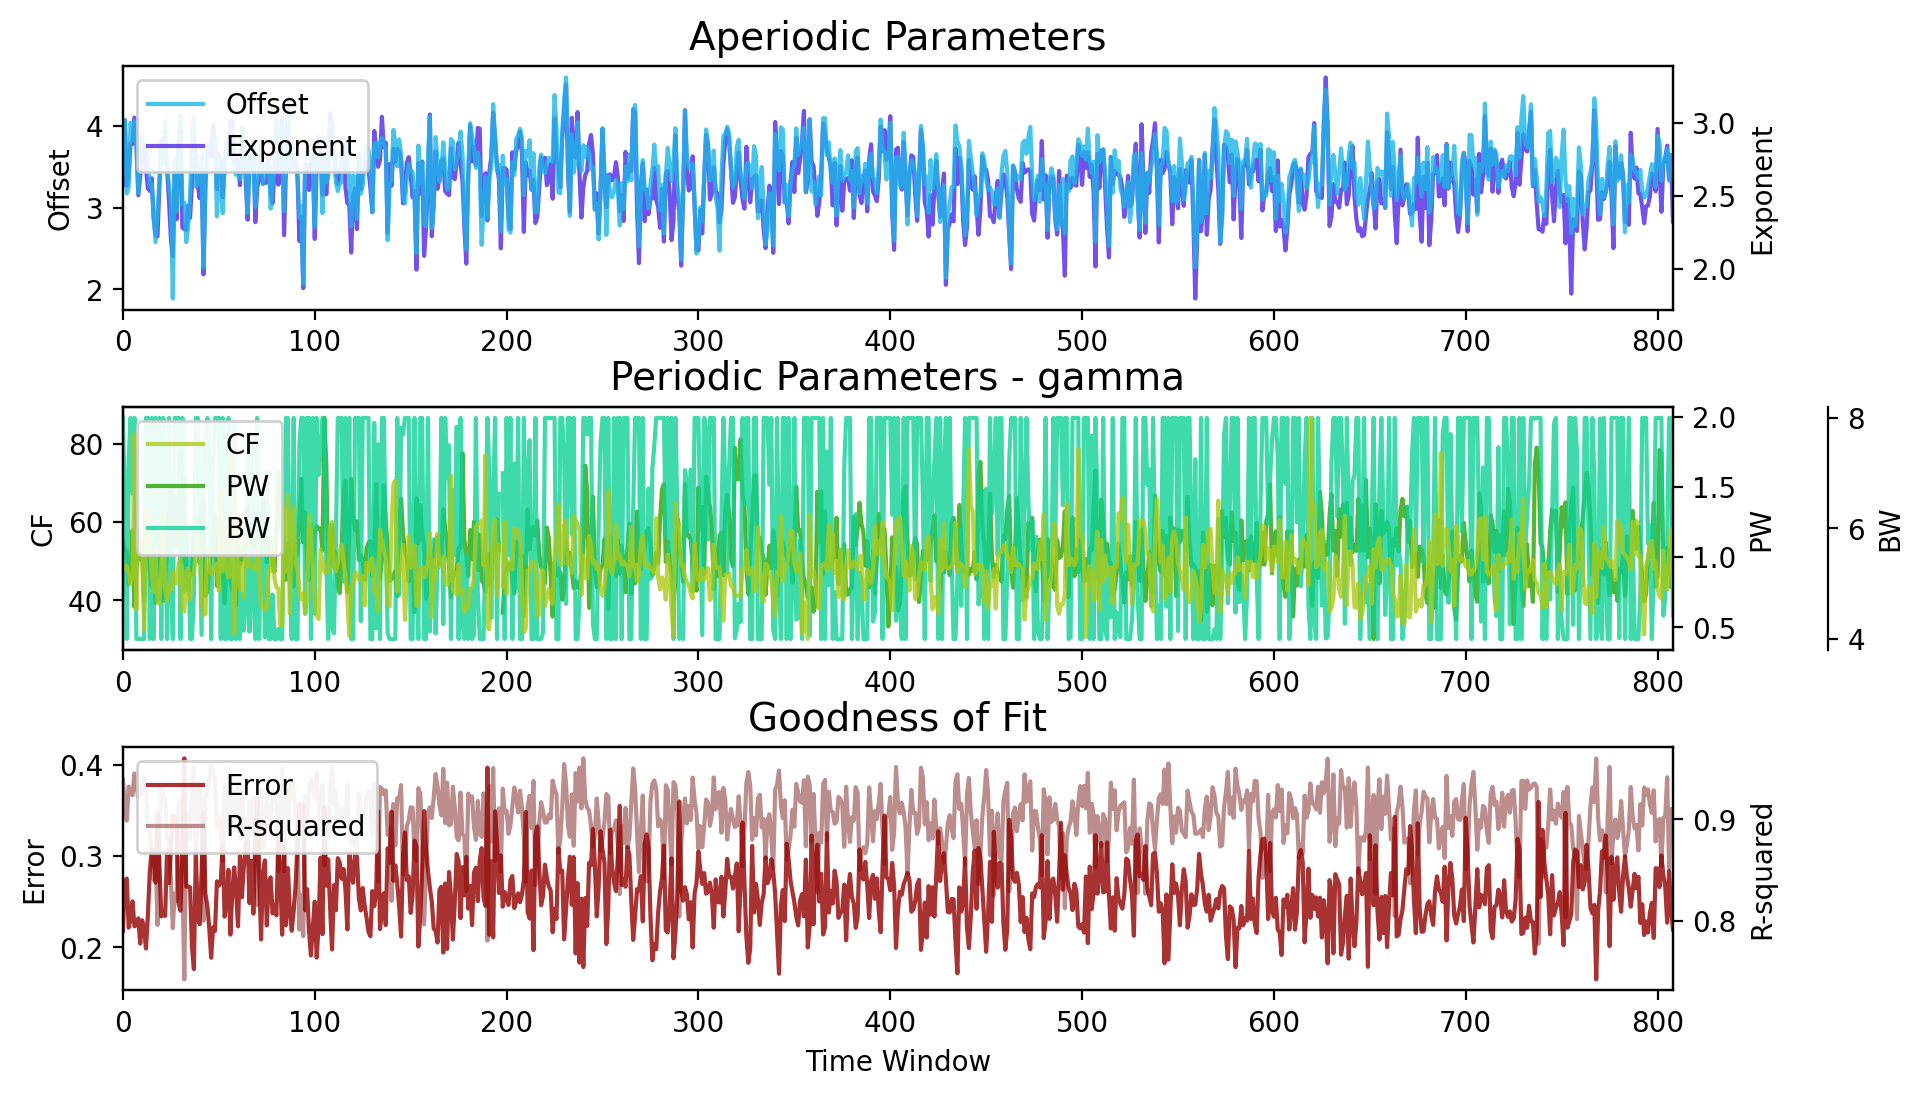

In [19]:
model_welch.report(peak_org=bands)

In [14]:
# ========== Classify gamma power per window ==========
# Get summary df
summary_df_welch = model_welch.to_df(peak_org=bands)

# Classify
high_inds_welch, low_inds_welch = classify_gamma_windows(summary_df_welch)



In [16]:
# ========== Merge adjacent windows into long blocks ==========

high_blocks_welch, high_total_welch = compute_block_stats(high_inds_welch, window_len_sec)
low_blocks_welch, low_total_welch = compute_block_stats(low_inds_welch, window_len_sec)



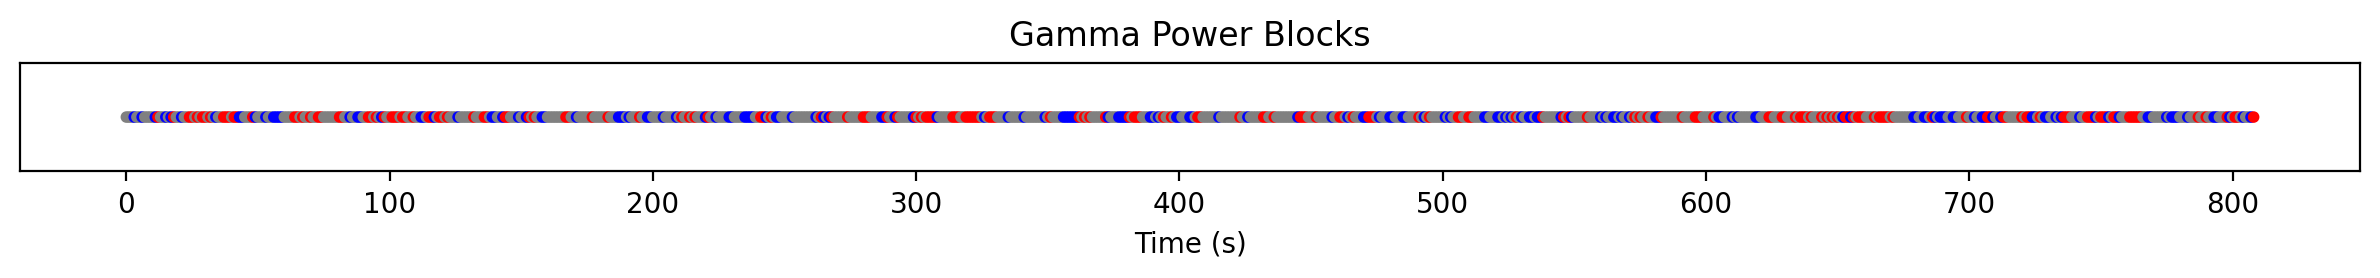

In [25]:
# ========== Visualize blocks ==========
plot_gamma_blocks(high_inds_welch, low_inds_welch, win_times_welch, window_len_sec, lfp_fs)



### Visualize specparam results for low vs high gamma windows (sanity check)

ValueError: x and y must have same first dimension, but have shapes (1251,) and (90,)

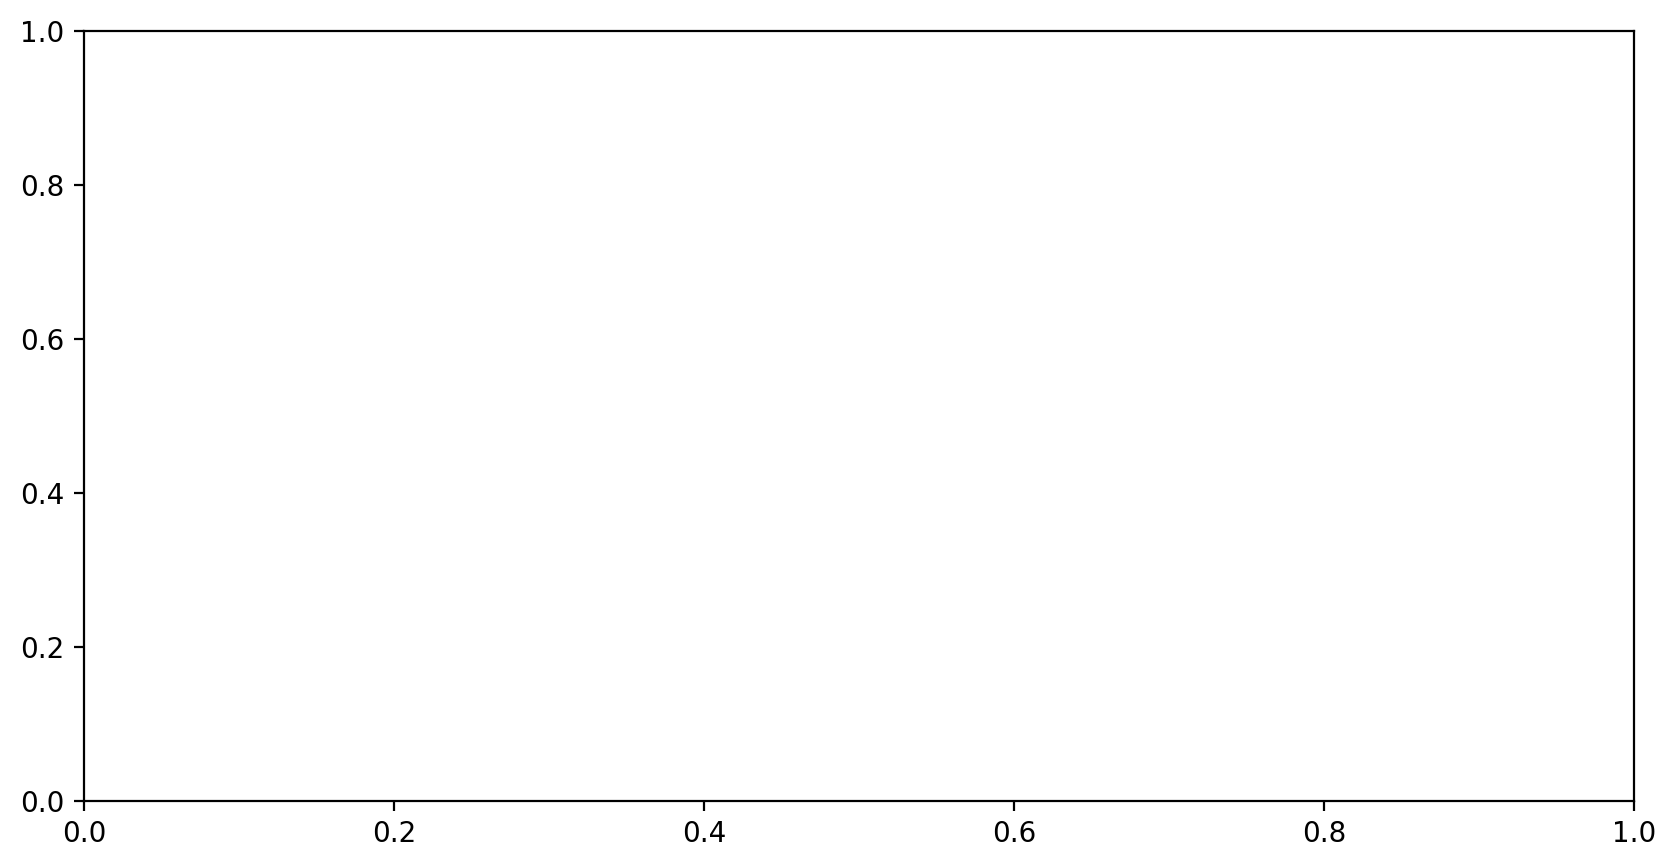

In [17]:
plot_avg_spectra(model_welch, freqs_welch, high_inds_welch, low_inds_welch)



### Replicate with multitapers

In [ ]:
# Use multitaper method instead of Welch
model_mt, freqs_mt, window_times_mt = compute_lfp_windows(
    lfp_signal=lfp_filt,
    fs=lfp_fs,
    method='multitaper',  
    window_length_sec=window_len_sec,
    step_size_sec=step_size_sec,
    freq_range=(1, 90),
    fooof_params={"max_n_peaks": 4, "verbose": False},
    multitaper_params={"bandwidth": 4}  
)

In [ ]:
gamma_band_name = "gamma"
gamma_powers_mt = summary_df_mt[f"{gamma_band_name}_peak_power"].values

# Same thresholding approach
high_thresh_mt = np.nanpercentile(gamma_powers_mt, 75)
low_thresh_mt = np.nanpercentile(gamma_powers_mt, 25)

high_windows_mt = [
    start for (start, _), pw in zip(window_times_mt, gamma_powers_mt) if pw >= high_thresh_mt
]
low_windows_mt = [
    start for (start, _), pw in zip(window_times_mt, gamma_powers_mt) if pw <= low_thresh_mt
]


In [ ]:
# Get start times of windows
start_times_mt = [start for (start, _) in window_times_mt]

# Get indices into foof_results
high_idxs_mt = [i for i, s in enumerate(start_times_mt) if s in high_windows_mt]
low_idxs_mt  = [i for i, s in enumerate(start_times_mt) if s in low_windows_mt]

# Plot
plot_average_foof_comparison(high_idxs_mt, low_idxs_mt, foof_results_mt, title="Multitaper: High vs Low Gamma",  ylim=shared_ylim)


# B) Hilbert amplitude burst for binary gamma no gamma classification 

#### 1. Filter the signal in +/- 15 Hz around that gamma peak

In [ ]:
gamma_peak = int(fm.peak_params_[0][0])
gamma_range = [gamma_peak - 15, gamma_peak+15]
#filter LFP data around that range
lfp_filt_gamma = butter_bandpass(lfp_filt, fs=lfp_fs, filt_freq=list(gamma_range), order=4)

#### 2. Get the analytic amplitude of the time series 

In [ ]:
gamma_amp = ndp.timefrequency.amp_by_time(lfp_filt_gamma, lfp_fs, gamma_range)

In [ ]:
xlim = (2000, 6000)
tidx = np.logical_and(lfp_times >= xlim[0],lfp_times < xlim[1])

# Plot the filtered signal and oscillation amplitude
ndp.plts.plot_instantaneous_measure(lfp_times[tidx], [lfp_filt_gamma[tidx], gamma_amp[tidx]],
                           measure='amplitude', lw=2, xlabel='',
                           labels=['filtered signal', 'amplitude'])

#### 3. Classify a burst as whenever the gamma analytic amplitude goes above some criterion (3x median), and ends when it drops below another criterion (1.5x mean)



#### Method: neurodsp burst detection on gamma filtered data


In [ ]:
xlim = (4000,80000)
tidx = np.logical_and(lfp_times_c42 >= xlim[0],lfp_times_c42 < xlim[1])

In [ ]:
# Settings for the dual threshold algorithm
amp_dual_thresh = (1, 2)
f_range = (gamma_peak-15, gamma_peak+15)



### Compute patch clamp spike features for cell 42

#### 4. compare the patched spike waveform for spikes that occur during an obvious gamma burst versus those are are obviously not in gamma. We’ll want to confirm this visually, looking at the time series as well.


In [ ]:
plt.plot(patch_times_c42[10000:1000000], patch_filt_c42[10000:1000000])

In [ ]:
sp.df_features

### Use detected spike indeces to determine if a spike occured during gamma peak or not

#### A) Get converted indices for gamma 'bursts'

In [ ]:
#convert to ms
ranges_burst = in_burst_to_burst_range_ms(is_burst)
gamma_bursts_ms = [(x/lfp_one_ms, y/lfp_one_ms) for x,y in ranges_burst]

#### B) Get converted indices for lowest amp no gamma 'bursts'. Select areas not in bursts with the lowest analytic amplitude

In [ ]:
ranges_not_burst = in_burst_to_burst_range_ms(np.invert(is_burst), ms_convert=False)

#### Select ranges with lowest analytical amplitude 

In [ ]:
not_burst_ms = get_lowest_analytical_amp(gamma_amp,ranges_not_burst, lfp_one_ms,thresh=1.0)

#### Visualize regions in gamma burst and low amp no gamma 

##### Gamma detection method 2

In [ ]:
visualize_lfp_gamma_regions(lfp_times_c42, lfp_filt_gamma_c42, gamma_bursts_ms, not_burst_ms, 
                            title = 'Visualization of gamma and non gamma regions in LFP, gamma detection', xlim=None)



#### C) Determine what spikes are in which group 

##### C.0) spikes in gamma vs non gamma regions 

In [ ]:
spk_times_ms = patch_times_c42[sp.spike_inds]

In [ ]:
spk_class_m2, spk_idx_m2, spk_idx_ms_m2 =  spk_lfp_class(spk_times_ms, not_burst_ms_m2, gamma_bursts_ms_m2)

spk_class_m3, spk_idx_m3, spk_idx_ms_m3 =  spk_lfp_class(spk_times_ms, not_burst_ms_m3, gamma_bursts_ms_m3)


In [ ]:
occurrence_m2 = {item: spk_class_m2.count(item) for item in spk_class_m2}
occurrence_m3 = {item: spk_class_m3.count(item) for item in spk_class_m3}

In [ ]:
occurrence_m2

In [ ]:
occurrence_m3

##### C.1) Distrubition of spikes in no gamma group by gamma analytical amplitude - VERY IMPORTANT!!!!!!!!!. I think the spikes in the low gamma group are occuring in the higher gamma timepoints (but that were not detected as "high gamma" group)

In [ ]:
# Take the absolute value of the analytical amplitude
abs_lfp_filt_gamma_c42 = np.abs(lfp_filt_gamma_c42)

# Initialize lists to store analytical amplitude and number of spikes
all_amp = []
all_num_spikes = []

# Iterate over each non-gamma subgroup
for burst in not_burst_ms_m3:
    # Determine analytical amplitude range covered by the subgroup
    burst_amp = abs_lfp_filt_gamma_c42[(lfp_times_c42 >= burst[0]) & (lfp_times_c42 <= burst[1])]
    all_amp.extend(burst_amp.tolist())
    
    # Count number of spikes within the subgroup
    spikes_in_subgroup = [spk_idx_ms_m3[i] for i in range(len(spk_idx_ms_m3)) if spk_class_m3[i] == 'no_gamma' and burst[0] <= spk_idx_ms_m3[i] <= burst[1]]
    all_num_spikes.extend([len(spikes_in_subgroup)] * len(burst_amp))

# Convert lists to numpy arrays
all_amp = np.array(all_amp).reshape(-1, 1)  # Reshape to column vector
all_num_spikes = np.array(all_num_spikes)

# Perform linear regression
model = LinearRegression()
model.fit(all_amp, all_num_spikes)

# Plot data points
plt.scatter(all_amp, all_num_spikes, color='blue', label='Data Points')

# Plot linear regression line
plt.plot(all_amp, model.predict(all_amp), color='red', label='Linear Regression')

plt.xlabel('Absolute Analytical Amplitude')
plt.ylabel('Number of Spikes')
plt.title('Linear Regression: Number of Spikes vs Absolute Analytical Amplitude')
plt.legend()
plt.grid(True)
plt.show()

##### C.2) Distrubition of number of spikes PER gamma/no gamma region

In [ ]:
# Initialize dictionaries to store counts for each subgroup in both groups
subgroup_counts = {'gamma': {}, 'no_gamma': {}}
subgroup_durations = {'gamma': {}, 'no_gamma': {}}

# Iterate through gamma bursts and count spikes in each subgroup
for idx, (start_time, end_time) in enumerate(gamma_bursts_ms_m3, start=1):
    subgroup_spike_count = sum(1 for spike_time, spike_class in zip(spk_idx_ms_m3, spk_class_m3) if start_time <= spike_time <= end_time and spike_class == 'gamma')
    subgroup_counts['gamma'][idx] = subgroup_spike_count
    subgroup_durations['gamma'][idx] = round(end_time - start_time, 2)

# Iterate through nongamma bursts and count spikes in each subgroup
for idx, (start_time, end_time) in enumerate(not_burst_ms_m3, start=1):
    subgroup_spike_count = sum(1 for spike_time, spike_class in zip(spk_idx_ms_m3, spk_class_m3) if start_time <= spike_time <= end_time and spike_class == 'no_gamma')
    subgroup_counts['no_gamma'][idx] = subgroup_spike_count
    subgroup_durations['no_gamma'][idx] = round(end_time - start_time, 2)


# Print subgroup spike counts for each group
for group, counts in subgroup_counts.items():
    print(f"Subgroup spike counts for {group}: {counts}")


In [ ]:
# Count the number of gamma and no gamma subgroups
num_gamma_subgroups = len(gamma_bursts_ms_m3)
num_no_gamma_subgroups = len(not_burst_ms_m3)

print("Number of Gamma Subgroups:", num_gamma_subgroups)
print("Number of No Gamma Subgroups:", num_no_gamma_subgroups)

In [ ]:
# Get spike numbers for gamma and no_gamma subgroups
gamma_spike_numbers = list(subgroup_counts['gamma'].values())
no_gamma_spike_numbers = list(subgroup_counts['no_gamma'].values())

# Create figure and main axes with larger size
fig, ax = plt.subplots(figsize=(10, 8))

# Plot histogram of spike rates on main axes
ax.hist(gamma_spike_numbers, bins=20, color='red', alpha=0.5, label='Gamma')
ax.hist(no_gamma_spike_numbers, bins=20, color='green', alpha=0.5, label='No Gamma')
ax.set_xlabel('Spike Rate (spikes/ms)')
ax.set_ylabel('Frequency')
ax.set_title('Histogram of Subgroup Spike Numbers')
ax.legend()


#Create inset axes
axin = inset_axes(ax, width="50%", height="50%", loc='upper right')

# Plot zoomed-in histogram on inset axes
axin.hist(gamma_spike_numbers, bins=20, color='red', alpha=0.5)
axin.hist(no_gamma_spike_numbers, bins=20, color='green', alpha=0.5)
axin.set_xlim(0, 60)  # Limit x-axis range for zoomed-in view
axin.set_ylim(0, 60)  # Limit y-axis range for zoomed-in view


# Show plot
plt.show()

##### C.3) Distribution of spikes in subgroups - adjusted group length - spike rate per second?

In [ ]:
#plot histogram with subgroup durations

# Get durations for gamma and no_gamma subgroups
gamma_durations = list(subgroup_durations['gamma'].values())
no_gamma_durations = list(subgroup_durations['no_gamma'].values())

# Create figure and main axes with larger size
fig, ax = plt.subplots(figsize=(10, 8))

# Plot histogram of subgroup durations on main axes
ax.hist(gamma_durations, bins=20, color='red', alpha=0.5, label='Gamma Durations')
ax.hist(no_gamma_durations, bins=20, color='green', alpha=0.5, label='No Gamma Durations')
ax.set_xlabel('Duration (ms)')
ax.set_ylabel('Frequency')
ax.set_title('Histogram of Subgroup Durations')
ax.legend()





plt.show()

In [ ]:
print("Gamma Durations:", gamma_durations)
print("No Gamma Durations:", no_gamma_durations)

In [ ]:
#Get spiking rate per ms for each subrgoup # Initialize dictionaries to store spike rates for each subgroup
subgroup_spike_rates = {'gamma': {}, 'no_gamma': {}}

# Calculate spike rates for gamma subgroups
for idx, (start_time, end_time) in enumerate(gamma_bursts_ms_m3, start=1):
    duration_ms = end_time - start_time
    spike_rate = subgroup_counts['gamma'][idx] / duration_ms
    subgroup_spike_rates['gamma'][idx] = spike_rate

# Calculate spike rates for no_gamma subgroups
for idx, (start_time, end_time) in enumerate(not_burst_ms_m3, start=1):
    duration_ms = end_time - start_time
    spike_rate = subgroup_counts['no_gamma'][idx] / duration_ms
    subgroup_spike_rates['no_gamma'][idx] = spike_rate

# Print spike rates for each subgroup
for group, rates in subgroup_spike_rates.items():
    print(f"Spike rates for {group} subgroups:")
    for idx, rate in rates.items():
        print(f"Subgroup {idx}: {rate:.2f} spikes/ms")


In [ ]:
#plot histogram with rates
# Get spike rates for gamma and no_gamma subgroups
gamma_spike_rates = list(subgroup_spike_rates['gamma'].values())
no_gamma_spike_rates = list(subgroup_spike_rates['no_gamma'].values())

# Create figure and main axes with larger size
fig, ax = plt.subplots(figsize=(10, 8))

# Plot histogram of spike rates on main axes
ax.hist(gamma_spike_rates, bins=20, color='red', alpha=0.5, label='Gamma')
ax.hist(no_gamma_spike_rates, bins=20, color='green', alpha=0.5, label='No Gamma')
ax.set_xlabel('Spike Rate (spikes/ms)')
ax.set_ylabel('Frequency')
ax.set_title('Histogram of Subgroup Spike Rates')
ax.legend()


#Create inset axes
axin = inset_axes(ax, width="50%", height="50%", loc='upper right')

# Plot zoomed-in histogram on inset axes
axin.hist(gamma_spike_rates, bins=20, color='red', alpha=0.5)
axin.hist(no_gamma_spike_rates, bins=20, color='green', alpha=0.5)
axin.set_xlim(0, 0.6)  # Limit x-axis range for zoomed-in view
axin.set_ylim(0, 20)  # Limit y-axis range for zoomed-in view


plt.show()

In [ ]:
# Filter out spike rates that are 0 spikes/ms
gamma_spike_rates_filtered = [rate for rate in gamma_spike_rates if rate > 0]
no_gamma_spike_rates_filtered = [rate for rate in no_gamma_spike_rates if rate > 0]

# Create figure and main axes with larger size
fig, ax = plt.subplots(figsize=(10, 8))

# Plot histogram of spike rates on main axes
ax.hist(gamma_spike_rates_filtered, bins=20, color='red', alpha=0.5, label='Gamma')
ax.hist(no_gamma_spike_rates_filtered, bins=20, color='green', alpha=0.5, label='No Gamma')
ax.set_xlabel('Spike Rate (spikes/ms)')
ax.set_ylabel('Frequency')
ax.set_title('Histogram of Subgroup Spike Rates (Excluding 0 spikes/ms)')
ax.legend()


# Create inset axes
axin = inset_axes(ax, width="50%", height="50%", loc='upper right')

# Plot zoomed-in histogram on inset axes
axin.hist(gamma_spike_rates_filtered, bins=20, color='red', alpha=0.5)
axin.hist(no_gamma_spike_rates_filtered, bins=20, color='green', alpha=0.5)
axin.set_xlim(0, 0.6)  # Limit x-axis range for zoomed-in view
axin.set_ylim(0, 20)  # Limit y-axis range for zoomed-in view


plt.show()

#### E) Compare features of gamma and no gamma spikes

In [ ]:
#Get features for gamma spikes
idx_gamma_m2 = np.where(np.array(spk_class_m2) == 'gamma')[0]
#get spike_idx 
spk_idx_gamma_m2 = np.asarray(spk_idx_m2)[np.asarray(idx_gamma_m2)]
spk_gamma_features_m2 = sp.df_features.iloc[spk_idx_gamma_m2]

In [ ]:
#Get features for gamma spikes
idx_gamma_m3 = np.where(np.array(spk_class_m3) == 'gamma')[0]
#get spike_idx 
spk_idx_gamma_m3 = np.asarray(spk_idx_m3)[np.asarray(idx_gamma_m3)]
spk_gamma_features_m3 = sp.df_features.iloc[spk_idx_gamma_m3]

In [ ]:
#Get features for no gamma spikes
idx_no_gamma_m2 = np.where(np.array(spk_class_m2) == 'no_gamma')[0]
#get spike_idx 
spk_idx_no_gamma_m2 = np.asarray(spk_idx_m2)[np.asarray(idx_no_gamma_m2)]
spk_no_gamma_features_m2 = sp.df_features.iloc[spk_idx_no_gamma_m2]

In [ ]:
#Get features for no gamma spikes
idx_no_gamma_m3 = np.where(np.array(spk_class_m3) == 'no_gamma')[0]
#get spike_idx 
spk_idx_no_gamma_m3 = np.asarray(spk_idx_m3)[np.asarray(idx_no_gamma_m3)]
spk_no_gamma_features_m3 = sp.df_features.iloc[spk_idx_no_gamma_m3]

#### Visualize categorized spikes and LFP groups


In [ ]:
gamma_spks_m2 = np.asarray(spk_idx_ms_m2)[np.asarray(idx_gamma_m2)]
no_gamma_spks_m2 = np.asarray(spk_idx_ms_m2)[np.asarray(idx_no_gamma_m2)]

gamma_spks_m3 = np.asarray(spk_idx_ms_m3)[np.asarray(idx_gamma_m3)]
no_gamma_spks_m3 = np.asarray(spk_idx_ms_m3)[np.asarray(idx_no_gamma_m3)]

###### Method 2

In [ ]:


visualize_lfp_gamma_regions(lfp_times_c42, lfp_filt_gamma_c42, gamma_bursts_ms_m2, not_burst_ms_m2, 
                            title = 'Visualization of gamma and non gamma regions in LFP, gamma detection method 2', xlim=(1000,15000), plot_spk=True, spk_gamma= gamma_spks_m2, spk_nogamma=no_gamma_spks_m2)


In [ ]:

visualize_lfp_gamma_regions(lfp_times_c42, lfp_filt_gamma_c42, gamma_bursts_ms_m2, not_burst_ms_m2, 
                            title = 'Visualization of gamma and non gamma regions in LFP, gamma detection method 2', plot_spk=True, spk_gamma= gamma_spks_m2, spk_nogamma=no_gamma_spks_m2)


##### Method 3

In [ ]:
visualize_lfp_gamma_regions(lfp_times_c42, lfp_filt_gamma_c42, gamma_bursts_ms_m3, not_burst_ms_m3, 
                            title = 'Visualization of gamma and non gamma regions in LFP, gamma detection method 3', xlim=(316000,346000), plot_spk=True, spk_gamma= gamma_spks_m3, spk_nogamma=no_gamma_spks_m3)


In [ ]:

visualize_lfp_gamma_regions(lfp_times_c42, lfp_filt_gamma_c42, gamma_bursts_ms_m3, not_burst_ms_m3, 
                            title = 'Visualization of gamma and non gamma regions in LFP, gamma detection method 2', plot_spk=True, spk_gamma= gamma_spks_m3, spk_nogamma=no_gamma_spks_m3)


##### Gamma features

In [ ]:
spk_gamma_features_m2

In [ ]:
spk_gamma_features_m3

#### Plot gamma features

In [ ]:


# Ensure inflection times are between 0 and 2 ms
df_drop_gamma_m2 = spk_gamma_features_m2.loc[spk_gamma_features_m2['inflection_time'] > 0.]
df_drop_gamma_m2 = df_drop_gamma_m2.loc[df_drop_gamma_m2['inflection_time'] < 2.]

# Remove low r-squares (ramping fits are especially noisy)
df_drop_gamma_m2 = df_drop_gamma_m2.loc[df_drop_gamma_m2['r_squared_exp']  >= .5]
df_drop_gamma_m2 = df_drop_gamma_m2.loc[df_drop_gamma_m2['r_squared_ramp'] >= .1]

# log10 ISIs
df_drop_gamma_m2[['isi']] = np.log10(df_drop_gamma_m2[['isi']])

# drop no-longer-used QC features
df_drop_gamma_m2 = df_drop_gamma_m2.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
df_drop_gamma_m2 = df_drop_gamma_m2.replace([np.inf, -np.inf], np.nan)

# Rotate labels
axes = pd.plotting.scatter_matrix(df_drop_gamma_m2, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
    
plt.show()

#### zscore outlier removal

In [ ]:
df_drop_gamma_m2_outliers = df_drop_gamma_m2[(np.abs(stats.zscore(df_drop_gamma_m2, nan_policy='omit')) < 3).all(axis=1)]



#### Plot spike shapes gamma method 2 

##### I am currently only plotting the average waveforms for method 3 

In [ ]:
#REMOVE WEIRD FITS 
spk_gamma_m2_notweird_fits_idx = [i for i in range(len(sp.ramp_poly_params[df_drop_gamma_m2_outliers.index])) if sp.ramp_poly_params[df_drop_gamma_m2_outliers.index][i][1] < 10]


In [ ]:
sp.plot(inds =  df_drop_gamma_m2_outliers.index[spk_gamma_m2_notweird_fits_idx], show_points=True)

In [ ]:
df_drop_gamma_m2_outliers = df_drop_gamma_m2_outliers.iloc[spk_gamma_m2_notweird_fits_idx]

In [ ]:
# plot
axes = pd.plotting.scatter_matrix(df_drop_gamma_m2_outliers, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
    
plt.show()

In [ ]:


# Ensure inflection times are between 0 and 2 ms
df_drop_gamma_m3 = spk_gamma_features_m3.loc[spk_gamma_features_m3['inflection_time'] > 0.]
df_drop_gamma_m3 = df_drop_gamma_m3.loc[df_drop_gamma_m3['inflection_time'] < 2.]

# Remove low r-squares (ramping fits are especially noisy)
df_drop_gamma_m3 = df_drop_gamma_m3.loc[df_drop_gamma_m3['r_squared_exp']  >= .5]
df_drop_gamma_m3 = df_drop_gamma_m3.loc[df_drop_gamma_m3['r_squared_ramp'] >= .1]

# log10 ISIs
df_drop_gamma_m3[['isi']] = np.log10(df_drop_gamma_m3[['isi']])

# drop no-longer-used QC features
df_drop_gamma_m3 = df_drop_gamma_m3.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
df_drop_gamma_m3 = df_drop_gamma_m3.replace([np.inf, -np.inf], np.nan)

# Rotate labels
axes = pd.plotting.scatter_matrix(df_drop_gamma_m3, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
    
plt.show()

In [ ]:
df_drop_gamma_m3_outliers = df_drop_gamma_m3[(np.abs(stats.zscore(df_drop_gamma_m3, nan_policy='omit')) < 3).all(axis=1)]


In [ ]:
sp.plot(inds = df_drop_gamma_m3_outliers.index, show_points=True)

In [ ]:
#REMOVE WEIRD FITS 
spk_gamma_m3_notweird_fits_idx = [i for i in range(len(sp.ramp_poly_params[df_drop_gamma_m3_outliers.index])) if sp.ramp_poly_params[df_drop_gamma_m3_outliers.index][i][1] < 10]


In [ ]:
sp.plot(inds =  df_drop_gamma_m3_outliers.index[spk_gamma_m3_notweird_fits_idx], show_points=True)


In [ ]:
df_drop_gamma_m3_outliers = df_drop_gamma_m3_outliers.iloc[spk_gamma_m3_notweird_fits_idx]

In [ ]:
# plot
axes = pd.plotting.scatter_matrix(df_drop_gamma_m3_outliers, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
    
plt.show()

In [ ]:
spikes_corr_gamma_m2 = df_drop_gamma_m2.corr()

# Plot the heatmap and annotation on it
sns.heatmap(spikes_corr_gamma_m2, xticklabels=spikes_corr_gamma_m2.columns, 
            yticklabels=spikes_corr_gamma_m2.columns, annot=True)
plt.show()

rho = df_drop_gamma_m2.corr()
pval = df_drop_gamma_m2.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

In [ ]:
spikes_corr_gamma_m2_outliers = df_drop_gamma_m2_outliers.corr()

# Plot the heatmap and annotation on it
sns.heatmap(spikes_corr_gamma_m2_outliers, xticklabels=spikes_corr_gamma_m2_outliers.columns, 
            yticklabels=spikes_corr_gamma_m2_outliers, annot=True)
plt.show()

rho =  df_drop_gamma_m2_outliers.corr()
pval =  df_drop_gamma_m2_outliers.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

In [ ]:
spikes_corr_gamma_m3 = df_drop_gamma_m3.corr()

# Plot the heatmap and annotation on it
sns.heatmap(spikes_corr_gamma_m3, xticklabels=spikes_corr_gamma_m3.columns, 
            yticklabels=spikes_corr_gamma_m3.columns, annot=True)
plt.show()

rho = df_drop_gamma_m3.corr()
pval = df_drop_gamma_m3.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

In [ ]:
spikes_corr_gamma_m3_outliers = df_drop_gamma_m3_outliers.corr()

# Plot the heatmap and annotation on it
sns.heatmap(spikes_corr_gamma_m3_outliers, xticklabels=spikes_corr_gamma_m3_outliers.columns, 
            yticklabels=spikes_corr_gamma_m3_outliers, annot=True)
plt.show()

rho =  df_drop_gamma_m3_outliers.corr()
pval =  df_drop_gamma_m3_outliers.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

##### No gamma features

In [ ]:
spk_no_gamma_features_m2

In [ ]:
spk_no_gamma_features_m3

In [ ]:
# Ensure inflection times are between 0 and 2 ms
df_drop_no_gamma_m2 = spk_no_gamma_features_m2.loc[spk_no_gamma_features_m2['inflection_time'] > 0.]
df_drop_no_gamma_m2 = df_drop_no_gamma_m2.loc[df_drop_no_gamma_m2['inflection_time'] < 2.]

# Remove low r-squares (ramping fits are especially noisy)
df_drop_no_gamma_m2 = df_drop_no_gamma_m2.loc[df_drop_no_gamma_m2['r_squared_exp']  >= .5]
df_drop_no_gamma_m2 = df_drop_no_gamma_m2.loc[df_drop_no_gamma_m2['r_squared_ramp'] >= .1]

# log10 ISIs
df_drop_no_gamma_m2[['isi']] = np.log10(df_drop_no_gamma_m2[['isi']])

# drop no-longer-used QC features
df_drop_no_gamma_m2 = df_drop_no_gamma_m2.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
df_drop_no_gamma_m2 = df_drop_no_gamma_m2.replace([np.inf, -np.inf], np.nan)

# Rotate labels
axes = pd.plotting.scatter_matrix(df_drop_no_gamma_m2, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
    
plt.show()

In [ ]:
df_drop_no_gamma_m2_outliers = df_drop_no_gamma_m2[(np.abs(stats.zscore(df_drop_no_gamma_m2, nan_policy='omit')) < 3).all(axis=1)]


In [ ]:
sp.plot(inds = df_drop_no_gamma_m2_outliers.index, show_points=True)

In [ ]:
# plot
axes = pd.plotting.scatter_matrix(df_drop_no_gamma_m2_outliers, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
    
plt.show()

In [ ]:
# Ensure inflection times are between 0 and 2 ms
df_drop_no_gamma_m3 = spk_no_gamma_features_m3.loc[spk_no_gamma_features_m3['inflection_time'] > 0.]
df_drop_no_gamma_m3 = df_drop_no_gamma_m3.loc[df_drop_no_gamma_m3['inflection_time'] < 2.]

# Remove low r-squares (ramping fits are especially noisy)
df_drop_no_gamma_m3 = df_drop_no_gamma_m3.loc[df_drop_no_gamma_m3['r_squared_exp']  >= .5]
df_drop_no_gamma_m3 = df_drop_no_gamma_m3.loc[df_drop_no_gamma_m3['r_squared_ramp'] >= .1]

# log10 ISIs
df_drop_no_gamma_m3[['isi']] = np.log10(df_drop_no_gamma_m3[['isi']])

# drop no-longer-used QC features
df_drop_no_gamma_m3 = df_drop_no_gamma_m3.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
df_drop_no_gamma_m3 = df_drop_no_gamma_m3.replace([np.inf, -np.inf], np.nan)

# Rotate labels
axes = pd.plotting.scatter_matrix(df_drop_no_gamma_m3, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
    
plt.show()

In [ ]:
df_drop_no_gamma_m3_outliers = df_drop_no_gamma_m3[(np.abs(stats.zscore(df_drop_no_gamma_m3, nan_policy='omit')) < 3).all(axis=1)]


In [ ]:
sp.plot(inds = df_drop_no_gamma_m3_outliers.index, show_points=True)

#### Overlay plots method 3

In [ ]:
sp.plot(inds = df_drop_gamma_m3_outliers.index, groups=True, ind_groups =[df_drop_gamma_m3_outliers.index, df_drop_no_gamma_m3_outliers.index], group_names = ['gamma m3', 'no gamma m3'])
       

In [ ]:
sp.plot(inds = df_drop_gamma_m3_outliers.index, groups=True, ind_groups =[df_drop_gamma_m3_outliers.index, df_drop_no_gamma_m3_outliers.index], group_names = ['gamma burst', 'no gamma burst'], show_points=False, plot_average =True, plot_average_std=True)
    
    

In [ ]:
# plot
axes = pd.plotting.scatter_matrix(df_drop_no_gamma_m3_outliers, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
    
plt.show()

In [ ]:
spikes_corr_no_gamma_m2 = df_drop_no_gamma_m2.corr()



rho = df_drop_no_gamma_m2.corr()
pval = df_drop_no_gamma_m2.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

print(rho)

# Plot the heatmap and annotation on it
sns.heatmap(spikes_corr_no_gamma_m2, xticklabels=spikes_corr_no_gamma_m2.columns, 
            yticklabels=spikes_corr_no_gamma_m2.columns, annot=rho)
plt.show()

In [ ]:
spikes_corr_no_gamma_m2_outliers = df_drop_no_gamma_m2_outliers.corr()

# Plot the heatmap and annotation on it
sns.heatmap(spikes_corr_no_gamma_m2_outliers, xticklabels=spikes_corr_no_gamma_m2_outliers.columns, 
            yticklabels=spikes_corr_no_gamma_m2_outliers, annot=True)
plt.show()

rho =  df_drop_no_gamma_m2_outliers.corr()
pval =  df_drop_no_gamma_m2_outliers.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

In [ ]:
spikes_corr_no_gamma_m3 = df_drop_no_gamma_m3.corr()

# Plot the heatmap and annotation on it
sns.heatmap(spikes_corr_no_gamma_m3, xticklabels=spikes_corr_no_gamma_m3.columns, 
            yticklabels=spikes_corr_no_gamma_m3.columns, annot=True)
plt.show()

rho = df_drop_no_gamma_m3.corr()
pval = df_drop_no_gamma_m3.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

In [ ]:
spikes_corr_no_gamma_m3_outliers = df_drop_no_gamma_m3_outliers.corr()

# Plot the heatmap and annotation on it
sns.heatmap(spikes_corr_no_gamma_m3_outliers, xticklabels=spikes_corr_no_gamma_m3_outliers.columns, 
            yticklabels=spikes_corr_no_gamma_m3_outliers, annot=True)
plt.show()

rho =  df_drop_no_gamma_m3_outliers.corr()
pval =  df_drop_no_gamma_m3_outliers.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

##### Compare features between gamma and no gamma spike groups (initial descriptive)

In [ ]:
columns = df_drop_gamma_m2.columns.values.tolist()

In [ ]:
df_drop_gamma_m2.mean()

In [ ]:
df_drop_gamma_m3.mean()

In [ ]:
df_drop_no_gamma_m2.mean()

In [ ]:
df_drop_no_gamma_m3.mean()

In [ ]:
df_drop_gamma_m2.std()

In [ ]:
df_drop_gamma_m3.std()

In [ ]:
df_drop_no_gamma_m2.std()

In [ ]:
df_drop_no_gamma_m3.std()

##### Stats for compared features

In [ ]:
# Combine group dataframes into one df with a tag column
groups_m2 = {'gamma': df_drop_gamma_m2, 'no_gamma': df_drop_no_gamma_m2}
df_concate_ggroups_m2 = pd.concat(groups_m2, names=['LFP_class'])
df_concate_ggroups_m2 = df_concate_ggroups_m2.reset_index(level=0)



In [ ]:
# Combine group dataframes into one df with a tag column
groups_m3 = {'gamma': df_drop_gamma_m3, 'no_gamma': df_drop_no_gamma_m3}
df_concate_ggroups_m3 = pd.concat(groups_m3, names=['LFP_class'])
df_concate_ggroups_m3 = df_concate_ggroups_m3.reset_index(level=0)


In [ ]:
#OUTLIER GROUPS
groups_m2_out = {'gamma': df_drop_gamma_m2_outliers, 'no_gamma': df_drop_no_gamma_m2_outliers}
df_concate_ggroups_m2_out = pd.concat(groups_m2_out, names=['LFP_class'])
df_concate_ggroups_m2_out = df_concate_ggroups_m2_out.reset_index(level=0)

groups_m3_out = {'gamma': df_drop_gamma_m3_outliers, 'no_gamma': df_drop_no_gamma_m3_outliers}
df_concate_ggroups_m3_out = pd.concat(groups_m3_out, names=['LFP_class'])
df_concate_ggroups_m3_out = df_concate_ggroups_m3_out.reset_index(level=0)


In [ ]:
df_concate_ggroups_m2

In [ ]:
# Count the occurrences of each type
type_counts = df_concate_ggroups_m3['LFP_class'].value_counts()

print("Number of 'gamma' spikes:", type_counts.get('gamma', 0))
print("Number of 'no gamma' spikes:", type_counts.get('no_gamma', 0))

In [ ]:
df_concate_ggroups_m3

In [ ]:
# initialize figure with 4 subplots in a row
fig, ax = plt.subplots(3, 3, figsize=(14, 12))
# add padding between the subplots
plt.subplots_adjust(hspace=.8) 

rows_count = 0
cols_count = 0

colors = ['brown', 'g', 'y', 'pink', 'darkred', 'darkorange', 'violet', 'darkgreen', 'lightblue']

for c in range(len(columns)):
    # draw boxplot - ramp amp 
    df_concate_ggroups_m2.boxplot(column=columns[c], by='LFP_class', ax=ax[rows_count][cols_count],
                                  color=dict(boxes=colors[c], whiskers='k', medians='k', caps='k'), patch_artist = True)
    
    cols_count = cols_count + 1
    
    if cols_count == 3:
        cols_count = 0
        rows_count = rows_count + 1



for subplot in ax:
    #subplot.set_xticklabels([])

    plt.show()

In [ ]:
# initialize figure with 4 subplots in a row
fig, ax = plt.subplots(3, 3, figsize=(14, 12))
# add padding between the subplots
plt.subplots_adjust(hspace=.8) 

rows_count = 0
cols_count = 0

colors = ['brown', 'g', 'y', 'pink', 'darkred', 'darkorange', 'violet', 'darkgreen', 'lightblue']

for c in range(len(columns)):
    # draw boxplot - ramp amp 
    df_concate_ggroups_m2_out.boxplot(column=columns[c], by='LFP_class', ax=ax[rows_count][cols_count],
                                  color=dict(boxes=colors[c], whiskers='k', medians='k', caps='k'), patch_artist = True)
    
    cols_count = cols_count + 1
    
    if cols_count == 3:
        cols_count = 0
        rows_count = rows_count + 1



for subplot in ax:
    #subplot.set_xticklabels([])

    plt.show()

In [ ]:
# initialize figure with 4 subplots in a row
fig, ax = plt.subplots(3, 3, figsize=(14, 12))
# add padding between the subplots
plt.subplots_adjust(hspace=.8) 

rows_count = 0
cols_count = 0

colors = ['brown', 'g', 'y', 'pink', 'darkred', 'darkorange', 'violet', 'darkgreen', 'lightblue']

for c in range(len(columns)):
    # draw boxplot - ramp amp 
    df_concate_ggroups_m3.boxplot(column=columns[c], by='LFP_class', ax=ax[rows_count][cols_count],
                                  color=dict(boxes=colors[c], whiskers='k', medians='k', caps='k'), patch_artist = True)
    
    cols_count = cols_count + 1
    
    if cols_count == 3:
        cols_count = 0
        rows_count = rows_count + 1



for subplot in ax:
    #subplot.set_xticklabels([])

    plt.show()
    

In [ ]:
# initialize figure with 4 subplots in a row
fig, ax = plt.subplots(3, 3, figsize=(14, 12))
# add padding between the subplots
plt.subplots_adjust(hspace=.8) 

rows_count = 0
cols_count = 0

colors = ['brown', 'g', 'y', 'pink', 'darkred', 'darkorange', 'violet', 'darkgreen', 'lightblue']

for c in range(len(columns)):
    # draw boxplot - ramp amp 
    df_concate_ggroups_m3_out.boxplot(column=columns[c], by='LFP_class', ax=ax[rows_count][cols_count],
                                  color=dict(boxes=colors[c], whiskers='k', medians='k', caps='k'), patch_artist = True)
    
    cols_count = cols_count + 1
    
    if cols_count == 3:
        cols_count = 0
        rows_count = rows_count + 1



for subplot in ax:
    #subplot.set_xticklabels([])

    plt.show()
    

In [ ]:
#remove exp constant outlier 
# Define threshold for outliers
threshold = 2  # You can adjust this threshold value as needed

# Calculate the z-score for the 'exp_const' column
z_scores = (df_concate_ggroups_m3_out['exp_const'] - df_concate_ggroups_m3_out['exp_const'].mean()) / df_concate_ggroups_m3_out['exp_const'].std()

# Filter the dataframe to exclude rows with outlier values
df_concate_ggroups_m3_out = df_concate_ggroups_m3_out[abs(z_scores) < threshold]

# Calculate the z-score for the 'exp_const' column
z_scores = (df_concate_ggroups_m3_out['ramp_amp'] - df_concate_ggroups_m3_out['ramp_amp'].mean()) / df_concate_ggroups_m3_out['ramp_amp'].std()

# Filter the dataframe to exclude rows with outlier values
df_concate_ggroups_m3_out = df_concate_ggroups_m3_out[abs(z_scores) < threshold]

In [ ]:
df_filtered = df_concate_ggroups_m3_out
# Initialize figure with 4 subplots in a row
fig, ax = plt.subplots(3, 3, figsize=(16, 14))
# Add padding between the subplots
plt.subplots_adjust(hspace=.8) 

rows_count = 0
cols_count = 0

# Define colors for gamma and no gamma groups
gamma_color = 'firebrick'
no_gamma_color = 'royalblue'

for c in range(len(columns)):
    # Draw violin plot without median
    sns.violinplot(x='LFP_class', y=columns[c], data=df_filtered, ax=ax[rows_count][cols_count],
                   palette={ 'gamma': gamma_color, 'no_gamma': no_gamma_color}, linewidth=1.5, inner=None)
    
    # Calculate mean and standard deviation values for each group
    gamma_mean = df_filtered[df_filtered['LFP_class'] == 'gamma'][columns[c]].mean()
    no_gamma_mean = df_filtered[df_filtered['LFP_class'] == 'no_gamma'][columns[c]].mean()
    gamma_std = df_filtered[df_filtered['LFP_class'] == 'gamma'][columns[c]].std()
    no_gamma_std = df_filtered[df_filtered['LFP_class'] == 'no_gamma'][columns[c]].std()

    # Add markers or lines to indicate mean
    ax[rows_count][cols_count].scatter([0], [gamma_mean], color='k', marker='o', label='Gamma Mean')
    ax[rows_count][cols_count].scatter([1], [no_gamma_mean], color='k', marker='o', label='No Gamma Mean')
    
    # Add vertical lines for standard deviation
    ax[rows_count][cols_count].vlines(0, gamma_mean - gamma_std, gamma_mean + gamma_std, colors='k', linestyles='dashed', label='Gamma Std')
    ax[rows_count][cols_count].vlines(1, no_gamma_mean - no_gamma_std, no_gamma_mean + no_gamma_std, colors='k', linestyles='dashed', label='No Gamma Std')

   
    
    # Perform t-test
    gamma_data = df_filtered[df_filtered['LFP_class'] == 'gamma'][columns[c]]
    no_gamma_data = df_filtered[df_filtered['LFP_class'] == 'no_gamma'][columns[c]]
    t_stat, p_val = ttest_ind(gamma_data, no_gamma_data)
    
    # Add stars for significance level
    if p_val < 0.01:
        stars = '**'
    elif p_val < 0.05:
        stars = '*'

    elif p_val < 0.001:
        stars = '***'
    else:
        stars = ''
        
    ax[rows_count][cols_count].text(0.5, 0.9, stars, horizontalalignment='center', verticalalignment='center', 
                                    transform=ax[rows_count][cols_count].transAxes, fontsize=30)  # Increase the font size of stars
    
    # Customize y-axis label
    ax[rows_count][cols_count].set_ylabel(columns[c].replace('_', ' '), fontsize=22)  # Increase the font size of y-axis label
    
    cols_count += 1
    
    if cols_count == 3:
        cols_count = 0
        rows_count += 1

# Customize x-axis labels
for ax_row in ax:
    for ax_col in ax_row:
        ax_col.set_xlabel('LFP Class', fontsize=32)  # Increase the font size of x-axis label
        ax_col.set_xticklabels(['Gamma Burst', 'Not Gamma Burst'], fontsize=30)  # Increase the font size of x-axis tick labels

# Hide grid lines
for subplot in ax.flatten():
    subplot.grid(False)

plt.show()


##### Run t-tests for variables

In [ ]:
for c in columns:
    print(c + " t-test")
    print(stats.ttest_ind(df_concate_ggroups_m2[c][df_concate_ggroups_m2['LFP_class'] == 'gamma'],
                    df_concate_ggroups_m2[c][df_concate_ggroups_m2['LFP_class'] == 'no_gamma'], nan_policy='omit'))

In [ ]:
for c in columns:
    print(c + " t-test")
    print(stats.ttest_ind(df_concate_ggroups_m2_out[c][df_concate_ggroups_m2_out['LFP_class'] == 'gamma'],
                    df_concate_ggroups_m2_out[c][df_concate_ggroups_m2_out['LFP_class'] == 'no_gamma'], nan_policy='omit'))

In [ ]:
for c in columns:
    print(c + " t-test")
    print(stats.ttest_ind(df_concate_ggroups_m3[c][df_concate_ggroups_m3['LFP_class'] == 'gamma'],
                    df_concate_ggroups_m3[c][df_concate_ggroups_m3['LFP_class'] == 'no_gamma'], nan_policy='omit'))

In [ ]:
for c in columns:
    print(c + " t-test")
    gamma_data = df_concate_ggroups_m3_out[c][df_concate_ggroups_m3_out['LFP_class'] == 'gamma']
    no_gamma_data = df_concate_ggroups_m3_out[c][df_concate_ggroups_m3_out['LFP_class'] == 'no_gamma']
    
    t_stat, p_val = stats.ttest_ind(gamma_data, no_gamma_data, nan_policy='omit')
    
    # Calculate Cohen's d
    pooled_std = np.sqrt((np.std(gamma_data, ddof=1)**2 + np.std(no_gamma_data, ddof=1)**2) / 2)
    cohens_d = (np.mean(gamma_data) - np.mean(no_gamma_data)) / pooled_std
    
    print("T-statistic:", t_stat)
    print("P-value:", p_val)
    print("Cohen's d:", cohens_d)
    print()

##### Compare cross correlation matrices

In [ ]:
upper(spikes_corr_gamma_m2)

In [ ]:
upper(spikes_corr_gamma_m3)

In [ ]:
upper(spikes_corr_no_gamma_m2)

In [ ]:
#extract upper triangles of correlation matrix
# Measure the similarity 
print(stats.spearmanr(upper(spikes_corr_gamma_m2), upper(spikes_corr_no_gamma_m2)))

In [ ]:
#extract upper triangles of correlation matrix
# Measure the similarity 
print(stats.spearmanr(upper(spikes_corr_gamma_m2), upper(spikes_corr_gamma_m3)))

In [ ]:
#extract upper triangles of correlation matrix
# Measure the similarity 
print(stats.spearmanr(upper(spikes_corr_gamma_m2), upper(spikes_corr_no_gamma_m3)))

In [ ]:
#extract upper triangles of correlation matrix
# Measure the similarity 
print(stats.spearmanr(upper(spikes_corr_gamma_m3), upper(spikes_corr_no_gamma_m2)))

##### Data is not independent so using this pvalues is misleading. To test for significance:

In [ ]:
"""Nonparametric permutation testing Monte Carlo"""
np.random.seed(0)
rhos = []
n_iter = 5000
true_rho, _ = stats.spearmanr(upper(spikes_corr_gamma_m2), upper(spikes_corr_no_gamma_m2))
# matrix permutation, shuffle the groups
m_ids = list(spikes_corr_gamma_m2.columns)
m2_v = upper(spikes_corr_no_gamma_m2)
for iter in range(n_iter):
  np.random.shuffle(m_ids) # shuffle list 
  r, _ = stats.spearmanr(upper(spikes_corr_gamma_m2.loc[m_ids, m_ids]), m2_v)  
  rhos.append(r)
perm_p = ((np.sum(np.abs(true_rho) <= np.abs(rhos)))+1)/(n_iter+1) # two-tailed test


f,ax = plt.subplots()
plt.hist(rhos,bins=20)
ax.axvline(true_rho,  color = 'r', linestyle='--')
ax.set(title=f"Permuted p: {perm_p:.3f}", ylabel="counts", xlabel="rho")
plt.show()

### Look at spike trains in gamma and non-gamma

In [ ]:
visualize_lfp_gamma_regions(lfp_times_c42, lfp_filt_gamma_c42, gamma_bursts_ms_m3, not_burst_ms_m3, 
                            title = 'Visualization of gamma and non gamma regions in LFP, gamma detection method 3', xlim=(0,40000), plot_spk=True, spk_gamma= gamma_spks_m3, spk_nogamma=no_gamma_spks_m3)

In [ ]:
#get spike raw traces for gamma sections 

gamma_traces = 

In [ ]:
#plot examples of gamma sections

In [ ]:
#get spike raw traces for non gamma sections 
nongamma_traces = 

In [ ]:
#plot examples of non gamma sections

### Look into burst/number of spikes info

In [ ]:
### compare number of spikes per burst between gamma and non gamma 

In [ ]:
### look at burst spike evolution - how does the shape of the first spike compare to the subsequent files